In [136]:
import numpy as np
import matplotlib.pyplot as plt
colors = [f"#{int(255 - i * 50):02x}{int(255 - i * 50):02x}{int(255 - i * 50):02x}" for i in range(4)]

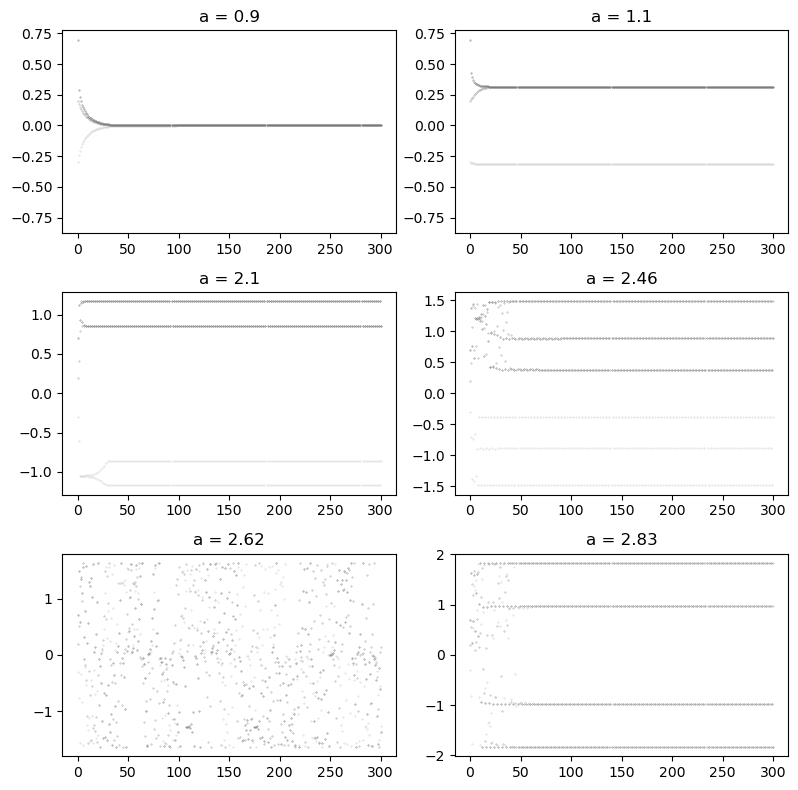

In [137]:
a_vals = [0.90, 1.10, 2.10, 2.46, 2.62, 2.83]
x_0_vals = [ -0.8, -0.3, 0.2, 0.7]

fig, ax = plt.subplots(3,2,figsize = (8,8))
ax = ax.flatten()
n = 300

x = np.zeros(301)
for j, x_0 in enumerate(x_0_vals):
    for i, (ax_i, a) in enumerate(zip(ax, a_vals)):

        x *= 0
        x[0] = x_0
        for k in range(n):
            x[k + 1] = a*x[k] - x[k]**3

        ax_i.plot(x, 'o', markersize = 0.3, color = colors[j])
        ax_i.set_title(f"a = {a}")
    
fig.tight_layout()
plt.savefig("1.pdf")

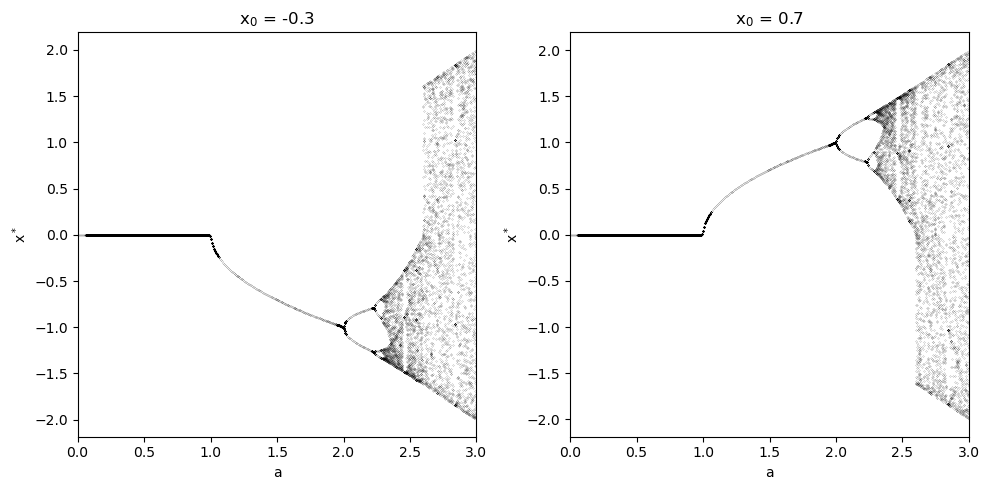

In [119]:
a_vals = np.linspace(0, 3, 400)
x_0_vals = [-0.3, 0.7]
fig, axs = plt.subplots(1,len(x_0_vals), figsize=  (10,5))
N = 300
for idx, (ax, x_0) in enumerate(zip(axs, x_0_vals)):
    for i, a in enumerate(a_vals):
        
        x = np.zeros(N +1)
        x[0] = x_0
        for j in range(N):
            x[j + 1] = a*x[j] - x[j]**3

        unique = np.unique(x[-50:])

        ax.plot(a*np.ones_like(unique), unique, 'o', color = 'k', markersize = 0.1)
        ax.set_title(r"x$_0$ = " + f"{x_0}")
        ax.set_ylabel(r"x$^*$")
        ax.set_xlabel("a")
        ax.set_xlim(a_vals[0], a_vals[-1])
fig.tight_layout()
plt.savefig("2.png", dpi = 500)

C:\Users\DELL\AppData\Local\Temp\ipykernel_19068\2579569606.py:19: RuntimeWarning: divide by zero encountered in log
  lapunovs.append(np.sum(np.log(np.abs(f_prim(x))))/N)


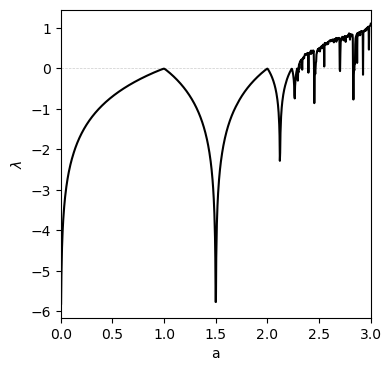

In [88]:

lapunovs = []

a_vals = np.linspace(0,3, 1000)
N = 600

x_0 = 0.2


fig,ax = plt.subplots(1,1, figsize = (4,4))

for i, a in enumerate(a_vals):

    f_prim = lambda x: a - 3*(x**2)
    x = np.zeros(N + 1)
    x[0] = x_0
    for j in range(N):
        x[j + 1] = a*x[j] - x[j]**3

    lapunovs.append(np.sum(np.log(np.abs(f_prim(x))))/N)

plt.plot(a_vals, lapunovs, color = 'k')
plt.plot(a_vals, np.zeros_like(a_vals), '--', linewidth = 0.5, color = 'k', alpha = 0.2)
plt.xlabel("a")
plt.ylabel(r"$\lambda$")
plt.xlim(np.min(a_vals), np.max(a_vals))
plt.savefig("3.pdf")
plt.show()


C:\Users\DELL\AppData\Local\Temp\ipykernel_19068\1316512960.py:18: RuntimeWarning: overflow encountered in scalar power
  x[j + 1] = a * x[j] - x[j]**3
C:\Users\DELL\AppData\Local\Temp\ipykernel_19068\1316512960.py:18: RuntimeWarning: invalid value encountered in scalar subtract
  x[j + 1] = a * x[j] - x[j]**3
C:\Users\DELL\AppData\Local\Temp\ipykernel_19068\1316512960.py:14: RuntimeWarning: overflow encountered in square
  f_prim = lambda x: a - 3 * (x**2)


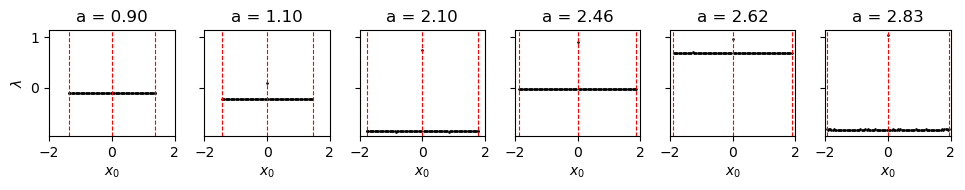

In [138]:
from matplotlib import cm

a_vals = [0.90, 1.10, 2.10, 2.46, 2.62, 2.83]


N = 10000
fig, axs = plt.subplots(1, len(a_vals), figsize=(10, 2), sharey=True)

for a_idx, a in enumerate(a_vals):
    x_0_vals=np.linspace(-2, 2, 101)
    lapunovs_x0 = []
    x_0_vals = np.append(x_0_vals, np.array([-np.sqrt(1 + a), np.sqrt(1 + a)]))
    for x_0 in x_0_vals:
        f_prim = lambda x: a - 3 * (x**2)
        x = np.zeros(N + 1)
        x[0] = x_0
        for j in range(N):
            x[j + 1] = a * x[j] - x[j]**3

        lapunov = np.nansum(np.log(np.abs(f_prim(x))))/N
        lapunovs_x0.append(lapunov)

    ax = axs[a_idx%len(axs)]
    ax.plot(x_0_vals, lapunovs_x0, 'o', color='k', markersize = 0.9)
    ax.set_title(f"a = {a:.2f}")
    ax.set_xlabel(r"$x_0$")
    ax.set_xlim(np.min(x_0_vals), np.max(x_0_vals))
    ax.axvline(x=np.sqrt(1 + a), color='r', linestyle='--', linewidth=0.8)
    ax.axvline(x=-np.sqrt(1 + a), color='r', linestyle='--', linewidth=0.8)
    ax.axvline(x=0, color='r', linestyle='--', linewidth=0.8)
    if a_idx % len(axs) == 0:
        ax.set_ylabel(r"$\lambda$")

fig.tight_layout()
plt.savefig("4.pdf")
plt.show()


In [90]:
a_vals = [0.90, 1.10, 2.10, 2.46, 2.62, 2.83]
x_0_vals=np.linspace(-2, 2, 100)
N = 100000

for a_idx, a in enumerate(a_vals):

    f_prim = lambda x: a - 3*(x**2)
    x = np.zeros(N + 1)
    x[0] = 0.2
    for j in range(N):
        x[j + 1] = a*x[j] - x[j]**3

    lapunov = np.nansum(np.log(np.abs(f_prim(x))))/(N+1)
    print(a, f"  {lapunov:.6}")

0.9   -0.105367
1.1   -0.223127
2.1   -0.857374
2.46   -0.0295363
2.62   0.692995
2.83   -0.82919


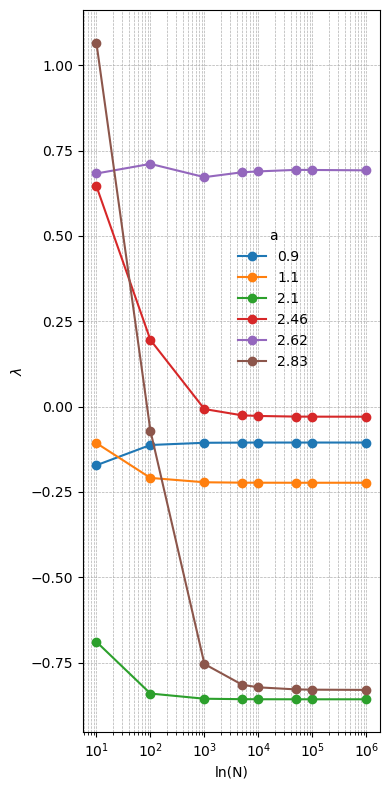

In [131]:
N_vals = [10, 100, 1000, 5000, 10000, 50000, 100000, 1000000]
lapunovs_N = []

fig, ax = plt.subplots(1,1,figsize = (4,8))
a_vals = [0.90, 1.10, 2.10, 2.46, 2.62, 2.83]
x_0 = 0.2

for a in a_vals:
    lapunovs_N = []
    for N in N_vals:
        f_prim = lambda x: a - 3*(x**2)
        x = np.zeros(N + 1)
        x[0] = x_0
        for j in range(N):
            x[j + 1] = a * x[j] - x[j]**3

        lapunov = np.nansum(np.log(np.abs(f_prim(x))))/N
        lapunovs_N.append(lapunov)

    ax.plot(N_vals, lapunovs_N, 'o-', label = f"{a}")
ax.legend(frameon = False, title = "a", bbox_to_anchor=(0.8, 0.6))
ax.set_xscale('log')
ax.set_xlabel("ln(N)")
ax.set_ylabel(r"$\lambda$")
ax.grid(True, which="both", linestyle="--", linewidth=0.5)
fig.tight_layout()
plt.savefig("5.pdf")
plt.show()
